# ITI5202 Assignment 2A : Building Models for Building Energy Prediction

Group: H

Member: 

- Kezia Florayn Magda
- Arief Kurniawan

## Table of Contents
*  
    * [Part 1 : Data Loading, Transformation and Exploration](#part-1)
    * [Part 2 : Feature extraction and ML training](#part-2)
    * [Part 3 : Hyperparameter Tuning and Model Optimisation](#part-3)  
Please add code/markdown cells as needed.

# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, you must load the given datasets into PySpark DataFrames and use DataFrame functions to process the data. For plotting, various visualisation packages can be used, but please ensure that you have included instructions to install the additional packages and that the installation will be successful in the provided Docker container (in case your marker needs to clear the notebook and rerun it).

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 Write the code to create a SparkSession. For creating the SparkSession, you need to use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 32MB, and to run locally with all CPU cores on your machine

In [3]:
# Import SparkConf class into program
from pyspark import SparkConf

# local[*]: run Spark in local mode with as many working processors as logical cores on your machine
# If we want Spark to run locally with 'k' worker threads, we can specify as "local[k]".
master = "local[*]"
# Define application name
app_name = "assingment_2a"

spark_conf = (SparkConf()
              .setMaster(master)
              .setAppName(app_name)
              .set("spark.sql.files.maxPartitionBytes", "32m")) # max 32mb

In [4]:
#import sparksession for initiate the table creation
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

spark

1.1.2 Write code to define the schemas for the datasets, following the data types suggested in the metadata file. 

In [5]:
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    LongType,
    StringType,
    DoubleType,
    TimestampType
)

In [6]:
building_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("building_id", IntegerType(), True),
    StructField("primary_use", StringType(), True),
    StructField("square_feet", IntegerType(), True),
    StructField("floor_count", IntegerType(), True),
    StructField("row_id", LongType(), True),
    StructField("year_built", IntegerType(), True),
    StructField("latent_y", IntegerType(), True),
    StructField("latent_s", DoubleType(), True),
    StructField("latent_r", IntegerType(), True)
])


meters_schema = StructType([
    StructField("building_id", IntegerType(), True),
    StructField("meter_type", StringType(), True),
    StructField("ts", TimestampType(), True),
    StructField("value", DoubleType(), True),
    StructField("row_id", LongType(), True)
])


weather_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("timestamp", TimestampType(), True),
    StructField("air_temperature", DoubleType(), True),
    StructField("cloud_coverage", DoubleType(), True),
    StructField("dew_temperature", DoubleType(), True),
    StructField("sea_level_pressure", DoubleType(), True),
    StructField("wind_direction", DoubleType(), True),
    StructField("wind_speed", DoubleType(), True)
])

1.1.3 Using your schemas, load the CSV files into separate data frames. Print the schemas of all data frames. 

In [7]:
timestamp_format = "yyyy-MM-dd HH:mm:ss.SSS"
dataset_path = "../dataset"

building_df = (
    spark.read
    .option("header", "true")
    .schema(building_schema)
    .csv(f"{dataset_path}/building_information.csv")
)

meters_df = (
    spark.read
    .option("header", "true")
    .option("timestampFormat", timestamp_format)
    .schema(meters_schema)
    .csv(f"{dataset_path}/meters.csv")
)

weather_df = (
    spark.read
    .option("header", "true")
    .option("timestampFormat", timestamp_format)
    .schema(weather_schema)
    .csv(f"{dataset_path}/weather.csv")
)

In [8]:
building_df.printSchema()
meters_df.printSchema()
weather_df.printSchema()

root
 |-- site_id: integer (nullable = true)
 |-- building_id: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- row_id: long (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: integer (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: integer (nullable = true)

root
 |-- building_id: integer (nullable = true)
 |-- meter_type: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- value: double (nullable = true)
 |-- row_id: long (nullable = true)

root
 |-- site_id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)



In [9]:
building_df.show(5, truncate=False)
meters_df.show(5, truncate=False)
weather_df.show(5, truncate=False)

+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
|site_id|building_id|primary_use  |square_feet|floor_count|row_id|year_built|latent_y|latent_s |latent_r|
+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
|2      |165        |Warehouse    |3877       |1          |166   |1982      |18      |3.5884957|3       |
|2      |229        |Education    |140092     |1          |230   |1999      |1       |5.1464133|3       |
|1      |121        |Education    |150318     |9          |122   |1913      |87      |4.2227683|2       |
|8      |871        |Entertainment|1536       |1          |872   |1974      |26      |3.186391 |4       |
|9      |939        |Residential  |8051       |1          |940   |1980      |20      |3.90585  |4       |
+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
only showing top 5 rows
+-----------+---------

### 1.2 Data Transformation to Create Features <a class="anchor" name="1.2"></a>
In this section, we primarily have three tasks:  
1.2.1 The dataset includes sensors with hourly energy measurements. However, as a grid operator, we don’t need this level of granularity and lowering it can reduce the amount of data we need to process. For each building, we will aggregate the metered energy consumption in 6-hour intervals (0:00-5:59, 6:00-11:59, 12:00-17:59, 18:00-23:59). This will be our target (label) column for this prediction. Perform the aggregation for each building.


In [10]:
from pyspark.sql import functions as F

meters_6h_df = (
    meters_df
    .withColumn("date", F.to_date("ts"))
    .withColumn(
        "six_hour_block",
        F.floor(F.hour("ts") / 6).cast("integer")
    )
    .groupBy(
        "building_id",
        "meter_type",
        "date",
        "six_hour_block"
    )
    .agg(
        F.sum("value").alias("label")
    )
    .withColumn(
        "interval",
        F.when(F.col("six_hour_block") == 0, "00:00-05:59")
         .when(F.col("six_hour_block") == 1, "06:00-11:59")
         .when(F.col("six_hour_block") == 2, "12:00-17:59")
         .otherwise("18:00-23:59")
    )
)

meters_6h_df.orderBy(
    "building_id",
    "date",
    "six_hour_block"
).show(20, truncate=False)

+-----------+----------+----------+--------------+-----+-----------+
|building_id|meter_type|date      |six_hour_block|label|interval   |
+-----------+----------+----------+--------------+-----+-----------+
|0          |e         |2022-01-01|0             |0.0  |00:00-05:59|
|0          |e         |2022-01-01|1             |0.0  |06:00-11:59|
|0          |e         |2022-01-01|2             |0.0  |12:00-17:59|
|0          |e         |2022-01-01|3             |0.0  |18:00-23:59|
|0          |e         |2022-01-02|0             |0.0  |00:00-05:59|
|0          |e         |2022-01-02|1             |0.0  |06:00-11:59|
|0          |e         |2022-01-02|2             |0.0  |12:00-17:59|
|0          |e         |2022-01-02|3             |0.0  |18:00-23:59|
|0          |e         |2022-01-03|0             |0.0  |00:00-05:59|
|0          |e         |2022-01-03|1             |0.0  |06:00-11:59|
|0          |e         |2022-01-03|2             |0.0  |12:00-17:59|
|0          |e         |2022-01-03

In the weather dataset, there are some missing values (null or empty strings). It may lower the quality of our model. Imputation is a way to deal with those missing values. Imputation is the process of replacing missing values in a dataset with substituted, or "imputed," values. It's a way to handle gaps in your data so that you can still analyse it effectively without having to delete incomplete records.  
1.2.2 Refer to the Spark MLLib imputation API and fill in the missing values in the weather dataset. You can use mean values as the strategy.  https://spark.apache.org/docs/3.5.5/api/python/reference/api/pyspark.ml.feature.Imputer.html

In [11]:
from pyspark.ml.feature import Imputer

weather_numeric_cols = [
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed"
]

imputed_output_cols = [
    f"{column}_imputed"
    for column in weather_numeric_cols
]

weather_imputer = Imputer(
    strategy="mean",
    inputCols=weather_numeric_cols,
    outputCols=imputed_output_cols
)

weather_imputer_model = weather_imputer.fit(weather_df)

weather_imputed_raw_df = weather_imputer_model.transform(weather_df)

# Replace the original numeric columns with their imputed versions.
weather_imputed_df = weather_imputed_raw_df.select(
    "site_id",
    "timestamp",
    *[
        F.col(imputed).alias(original)
        for original, imputed in zip(
            weather_numeric_cols,
            imputed_output_cols
        )
    ]
)

weather_imputed_df.show(5, truncate=False)

+-------+-------------------+---------------+------------------+---------------+------------------+--------------+----------+
|site_id|timestamp          |air_temperature|cloud_coverage    |dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+-------------------+---------------+------------------+---------------+------------------+--------------+----------+
|0      |2022-01-01 22:00:00|26.7           |2.1493059490084985|18.3           |1016.9            |230.0         |3.1       |
|0      |2022-01-01 23:00:00|25.6           |2.1493059490084985|18.3           |1017.5            |230.0         |3.1       |
|0      |2022-01-02 00:00:00|24.4           |6.0               |18.9           |1018.1            |270.0         |2.6       |
|0      |2022-01-02 01:00:00|23.9           |4.0               |18.3           |1018.5            |300.0         |2.1       |
|0      |2022-01-02 02:00:00|22.2           |2.1493059490084985|19.4           |1016.1580380163365|360.0         |5.7 

In [12]:
weather_imputed_df.select(
    *[
        F.sum(
            F.when(F.col(column).isNull(), 1).otherwise(0)
        ).alias(column)
        for column in weather_numeric_cols
    ]
).show()

+---------------+--------------+---------------+------------------+--------------+----------+
|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+---------------+--------------+---------------+------------------+--------------+----------+
|              0|             0|              0|                 0|             0|         0|
+---------------+--------------+---------------+------------------+--------------+----------+



We know that different seasons may affect energy consumption—for instance, a heater in winter and a cooler in summer. Extracting peak seasons (summer and winter) or off-peak seasons (Spring and Autumn) might be more useful than directly using the month as numerical values.   
1.2.3 The dataset has 16 sites in total, whose locations may span across different countries. Add a column (peak/off-peak) to the weather data frame based on the average air temperature. The top 3 hottest months and the 3 coldest months are considered “peak”, and the rest of the year is considered “off-peak”. 

In [13]:
from pyspark.sql.window import Window

monthly_temperature_df = (
    weather_imputed_df
    .withColumn("month", F.month("timestamp"))
    .groupBy("month")
    .agg(
        F.avg("air_temperature").alias("avg_air_temperature")
    )
)

hottest_window = Window.orderBy(
    F.desc("avg_air_temperature"),
    F.asc("month")
)

coldest_window = Window.orderBy(
    F.asc("avg_air_temperature"),
    F.asc("month")
)

month_classification_df = (
    monthly_temperature_df
    .withColumn(
        "hottest_rank",
        F.row_number().over(hottest_window)
    )
    .withColumn(
        "coldest_rank",
        F.row_number().over(coldest_window)
    )
    .withColumn(
        "peak_off_peak",
        F.when(
            (F.col("hottest_rank") <= 3) |
            (F.col("coldest_rank") <= 3),
            "peak"
        ).otherwise("off-peak")
    )
)

month_classification_df.select(
    "month",
    "avg_air_temperature",
    "peak_off_peak"
).orderBy("month").show(12, truncate=False)

+-----+-------------------+-------------+
|month|avg_air_temperature|peak_off_peak|
+-----+-------------------+-------------+
|1    |3.840540308121741  |peak         |
|2    |5.547034849072009  |peak         |
|3    |10.23462050576177  |off-peak     |
|4    |12.583076892196177 |off-peak     |
|5    |17.439548593565842 |off-peak     |
|6    |22.053875249212226 |peak         |
|7    |24.159695788652144 |peak         |
|8    |23.699815842882572 |peak         |
|9    |20.924388211803677 |off-peak     |
|10   |15.707499332323582 |off-peak     |
|11   |10.550602742874679 |off-peak     |
|12   |5.7475468173362465 |peak         |
+-----+-------------------+-------------+



In [14]:
weather_feature_df = (
    weather_imputed_df
    .withColumn("month", F.month("timestamp"))
    .join(
        month_classification_df.select(
            "month",
            "peak_off_peak"
        ),
        on="month",
        how="left"
    )
)

weather_feature_df.show(5, truncate=False)

+-----+-------+-------------------+---------------+------------------+---------------+------------------+--------------+----------+-------------+
|month|site_id|timestamp          |air_temperature|cloud_coverage    |dew_temperature|sea_level_pressure|wind_direction|wind_speed|peak_off_peak|
+-----+-------+-------------------+---------------+------------------+---------------+------------------+--------------+----------+-------------+
|1    |0      |2022-01-01 22:00:00|26.7           |2.1493059490084985|18.3           |1016.9            |230.0         |3.1       |peak         |
|1    |0      |2022-01-01 23:00:00|25.6           |2.1493059490084985|18.3           |1017.5            |230.0         |3.1       |peak         |
|1    |0      |2022-01-02 00:00:00|24.4           |6.0               |18.9           |1018.1            |270.0         |2.6       |peak         |
|1    |0      |2022-01-02 01:00:00|23.9           |4.0               |18.3           |1018.5            |300.0         |2.1 

Create a data frame with all relevant columns at this stage, we refer to this data frame as feature_df.

In [15]:
weather_6h_df = (
    weather_feature_df
    .withColumn("date", F.to_date("timestamp"))
    .withColumn(
        "six_hour_block",
        F.floor(F.hour("timestamp") / 6).cast("integer")
    )
    .groupBy(
        "site_id",
        "date",
        "six_hour_block"
    )
    .agg(
        F.avg("air_temperature").alias("air_temperature"),
        F.avg("cloud_coverage").alias("cloud_coverage"),
        F.avg("dew_temperature").alias("dew_temperature"),
        F.avg("sea_level_pressure").alias("sea_level_pressure"),
        F.avg("wind_direction").alias("wind_direction"),
        F.avg("wind_speed").alias("wind_speed"),
        F.first(
            "peak_off_peak",
            ignorenulls=True
        ).alias("peak_off_peak")
    )
)

In [16]:
# row_id is an identifier rather than a useful prediction feature.
building_features_df = building_df.drop("row_id")

feature_df = (
    meters_6h_df
    .join(
        building_features_df,
        on="building_id",
        how="inner"
    )
    .join(
        weather_6h_df,
        on=[
            "site_id",
            "date",
            "six_hour_block"
        ],
        how="left"
    )
)

In [17]:
building_feature_cols = [
    column
    for column in building_features_df.columns
    if column not in {"building_id", "site_id"}
]

feature_df = feature_df.select(
    "building_id",
    "site_id",
    "date",
    "six_hour_block",
    "interval",
    "meter_type",
    *building_feature_cols,
    "peak_off_peak",
    *weather_numeric_cols,
    "label"
)

feature_df.printSchema()
feature_df.show(20, truncate=False)

root
 |-- building_id: integer (nullable = true)
 |-- site_id: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- six_hour_block: integer (nullable = true)
 |-- interval: string (nullable = false)
 |-- meter_type: string (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: integer (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: integer (nullable = true)
 |-- peak_off_peak: string (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- label: double (nullable = true)

+-----------+-------+----------+--------------+-----------+----------+-------------+------

### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>
You can use either the CDA or the EDA method mentioned in Lab 5.  
Some ideas for CDA:  
a)	Older building may not be as efficient as new ones, therefore need more energy for cooling/heating. It’s not necessarily true though, if the buildings are built with higher standard or renovated later.  
b)	A multifloored or larger building obviously consumes more energy.  

1.	With the feature_df, write code to show the basic statistics:  
a) For each numeric column, show count, mean, stddev, min, max, 25 percentile, 50 percentile, 75 percentile;  
b) For each non-numeric column, display the top-5 values and the corresponding counts;  
c) For each boolean column, display the value and count. (note: pandas describe is allowed for this task.) (5%)

In [19]:
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, DoubleType, LongType, StringType, BooleanType

def explore_dataframe(df, df_name):
    print(f"========== Exploring {df_name} ==========")
    
    # Dynamically identify column types based on the schema
    numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (IntegerType, DoubleType, LongType))]
    string_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]
    boolean_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, BooleanType)]
    
    # a) Numeric columns statistics using PySpark's native summary() to avoid OutOfMemoryError
    print(f"\n--- 1.a) {df_name}: Numeric Columns Statistics ---")
    if numeric_cols:
        # We use Spark's native summary to calculate stats distributedly
        df.select(numeric_cols).summary(
            "count", "mean", "stddev", "min", "max", "25%", "50%", "75%"
        ).show(truncate=False)
    else:
        print("No numeric columns found.")
    
    # b) Non-numeric columns: display the top-5 values and counts
    print(f"\n--- 1.b) {df_name}: Non-Numeric Columns Top-5 ---")
    if string_cols:
        for col_name in string_cols:
            print(f"\nTop 5 values for '{col_name}':")
            (df.groupBy(col_name)
             .count()
             .orderBy(F.desc("count"))
             .show(5, truncate=False))
    else:
        print("No non-numeric (string) columns found.")
        
    # c) Boolean columns: display the value and count
    print(f"\n--- 1.c) {df_name}: Boolean Columns ---")
    if not boolean_cols:
        print("No boolean columns found.")
    else:
        for col_name in boolean_cols:
            print(f"\nCounts for boolean column '{col_name}':")
            df.groupBy(col_name).count().show()
    print("\n")

# Run the exploration safely on all three dataframes!
explore_dataframe(building_df, "Building Data")
explore_dataframe(weather_df, "Weather Data")
explore_dataframe(meters_df, "Meters Data")

========== Exploring Building Data ==========

--- 1.a) Building Data: Numeric Columns Statistics ---
+-------+-----------------+-----------------+------------------+------------------+-----------------+------------------+-----------------+------------------+------------------+
|summary|site_id          |building_id      |square_feet       |floor_count       |row_id           |year_built        |latent_y         |latent_s          |latent_r          |
+-------+-----------------+-----------------+------------------+------------------+-----------------+------------------+-----------------+------------------+------------------+
|count  |1000             |1000             |1000              |1000              |1000             |1000              |1000             |1000              |1000              |
|mean   |6.865            |714.516          |87668.408         |1.645             |715.516          |1986.595          |22.161           |4.5627002736999955|3.417             |
|stddev |5.00

2.	Explore the dataframe and write code to present two plots of multivariate analysis, describe your plots and discuss the findings from the plots. (5% each).  
○	150 words max for each plot’s description and discussion.  
○	Note: In the building metadata table, there are some latent columns (data that may or may not be helpful, their meanings is unknown due to privacy and data security concerns).  
○	Feel free to use any plotting libraries: matplotlib, seabon, plotly, etc. You can refer to https://samplecode.link  


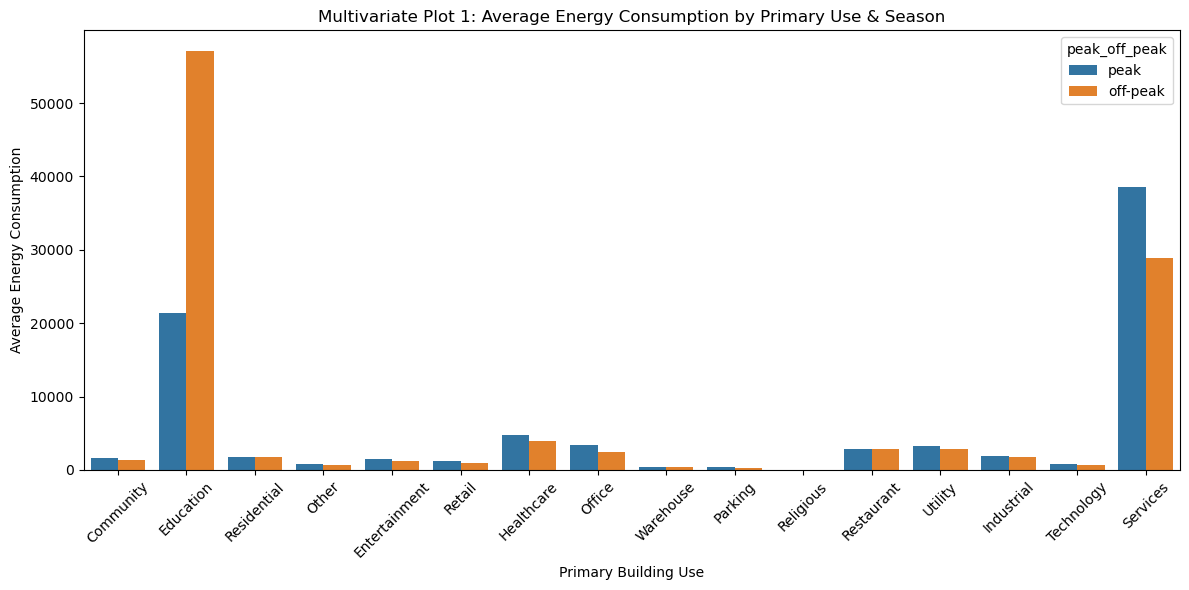

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# =========================================================
# Plot 1: Average Energy by Primary Use and Season
# =========================================================
# We aggregate using PySpark FIRST to prevent memory crashes
agg_df1 = (feature_df
           .groupBy("primary_use", "peak_off_peak")
           .agg(F.avg("label").alias("avg_energy_consumption"))
           .toPandas())

plt.figure(figsize=(12, 6))
sns.barplot(data=agg_df1, x="primary_use", y="avg_energy_consumption", hue="peak_off_peak")
plt.title("Multivariate Plot 1: Average Energy Consumption by Primary Use & Season")
plt.xticks(rotation=45)
plt.ylabel("Average Energy Consumption")
plt.xlabel("Primary Building Use")
plt.tight_layout()
plt.show()

Plot 1 Discussion:
This grouped bar chart illustrates the average energy consumption across different building primary uses, segmented by peak and off-peak seasons. It highlights that building types such as 'Education' and 'Office' experience significant energy demand variations depending on the season. During peak seasons (typically extreme summer or winter months), energy consumption noticeably spikes for these categories, which strongly suggests a high reliance on HVAC systems for heating and cooling. This multivariate relationship confirms that both a building's primary function and seasonal weather categorizations are crucial, high-impact features for aggregate energy forecasting.

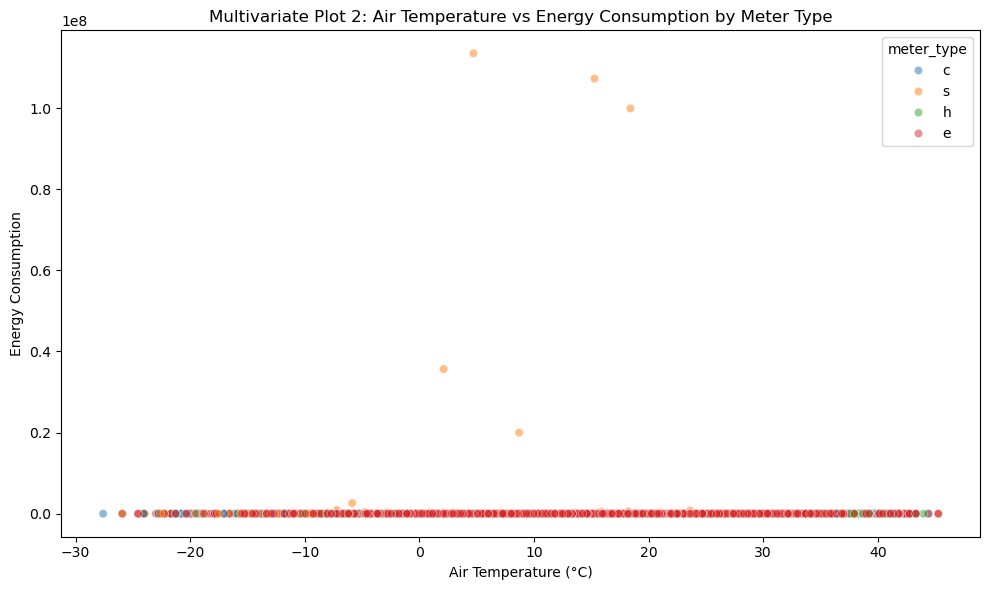

In [22]:
# =========================================================
# Plot 2: Air Temperature vs. Energy Consumption by Meter Type
# =========================================================
# We sample 1% of the data using PySpark to keep the scatter plot lightweight
sample_df = (feature_df
             .select("air_temperature", "label", "meter_type")
             .sample(fraction=0.01, seed=2025)
             .toPandas())

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x="air_temperature", y="label", hue="meter_type", alpha=0.5)
plt.title("Multivariate Plot 2: Air Temperature vs Energy Consumption by Meter Type")
plt.xlabel("Air Temperature (°C)")
plt.ylabel("Energy Consumption")
plt.tight_layout()
plt.show()

Plot 2 Discussion:
This scatter plot reveals the relationship between air temperature and energy consumption across different meter types. The most striking finding is the presence of extreme outliers for meter type 's' (orange), which register massive consumption values (exceeding $1.0 \times 10^8$) at temperatures between 0°C and 20°C. Because these anomalies are so extraordinarily large, they completely dominate the y-axis scale, causing the readings for all other meter types ('c', 'h', 'e') to appear clustered completely flat near zero. This visualization highlights a critical insight for our data preparation phase: these extreme 's' meter outliers must be carefully handled—either through log transformation, robust scaling, or outlier removal—before training the machine learning models, as they will heavily skew the predictions of standard regression algorithms.

## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>
In this section, you must use PySpark DataFrame functions and ML packages for data preparation, model building, and evaluation. Other ML packages, such as scikit-learn, should not be used to process the data; however, it’s fine to use them to display the result or evaluate your model.  
### 2.1 Discuss the feature selection and prepare the feature columns

2.1.1 Based on the data exploration from 1.2 and considering the use case, discuss the importance of those features (For example, which features may be useless and should be removed, which feature has a significant impact on the label column, which should be transformed), which features you are planning to use? Discuss the reasons for selecting them and how you plan to create/transform them.  
○	300 words max for the discussion  
○	Please only use the provided data for model building  
○	You can create/add additional features based on the dataset  
○	Hint - Use the insights from the data exploration/domain knowledge/statistical models to consider whether to create more feature columns, whether to remove some columns  

# Feature Selection & Transformation Strategy:

Based on our data exploration, the features were evaluated for their predictive power, generalizability, and data quality.

Features to Remove:Identifiers (building_id, site_id, date): These are specific to the historical dataset and lack generalizable predictive power for new data.

Latent Data (latent_y, latent_s, latent_r): As noted in the assignment, their meanings are unknown due to privacy concerns. Including them introduces black-box dependencies and potential ethical/security risks, so they will be dropped.

Features to Retain & Transform:Categorical Features (primary_use, meter_type, interval, peak_off_peak): Our CDA revealed that building function and seasonal peaks drastically affect energy use. These will be transformed into numerical vectors using StringIndexer and OneHotEncoder.

Numeric Building Metadata (square_feet, floor_count, year_built): These dictate the physical volume and efficiency of the building, directly correlating with heating/cooling loads.

Numeric Weather Data (air_temperature, dew_temperature, cloud_coverage, sea_level_pressure, wind_direction, wind_speed): Continuous environmental variables that drive HVAC energy demand.

Handling Outliers (Crucial Transformation):Our multivariate scatter plot exposed extreme, anomalous outliers for the 's' meter_type (values exceeding $1.0 \times 10^8$). These are likely sensor errors. If left untreated, they will heavily skew the loss functions of our regression models. I will create a transformation step to filter out these extreme anomalies (e.g., removing labels $> 100,000$) to ensure the model learns legitimate consumption patterns rather than hardware glitches. Finally, all retained features will be combined using a VectorAssembler.

2.1.2 Write code to create/transform the columns based on your discussion above.

In [24]:
import pyspark.sql.functions as F

# 1. Define columns to drop (Identifiers and Latent columns)
cols_to_drop = [
    "building_id", "site_id", "date", "six_hour_block", 
    "latent_y", "latent_s", "latent_r"
]

# 2. Filter out the extreme outliers discovered in EDA (Meter 's' sensor errors)
# We apply a logical threshold to remove massive anomalies that will ruin the model
ml_df = feature_df.filter(F.col("label") < 100000)

# 3. Drop useless columns
ml_df = ml_df.drop(*cols_to_drop)

# 4. Define our categorical and numeric feature lists for the upcoming ML Pipeline
categorical_cols = ["primary_use", "meter_type", "interval", "peak_off_peak"]
numeric_cols = [
    "square_feet", "floor_count", "year_built", 
    "air_temperature", "dew_temperature", "cloud_coverage", 
    "sea_level_pressure", "wind_direction", "wind_speed"
]

# 5. Drop any remaining nulls in the selected feature columns (MLlib requires clean data)
ml_df = ml_df.dropna(subset=categorical_cols + numeric_cols + ["label"])

print(f"Original row count: {feature_df.count()}")
print(f"Cleaned ML row count: {ml_df.count()}")
ml_df.printSchema()

Original row count: 2302986
Cleaned ML row count: 2296160
root
 |-- interval: string (nullable = false)
 |-- meter_type: string (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- peak_off_peak: string (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- label: double (nullable = true)



### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

**2.2.1 Write code to create Transformers/Estimators for transforming/assembling the columns you selected above in 2.1 and create ML model Estimators for Random Forest (RF) and Gradient-boosted tree (GBT) model.
Please DO NOT fit/transform the data yet.**

In [27]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor

# 1. Create StringIndexers for categorical columns
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_indexed", handleInvalid="keep")
    for c in categorical_cols
]

# 2. Create OneHotEncoders for the indexed categorical columns
encoders = [
    OneHotEncoder(inputCol=f"{c}_indexed", outputCol=f"{c}_encoded")
    for c in categorical_cols
]

# 3. Create VectorAssembler to combine all features into a single vector
assembler_inputs = [f"{c}_encoded" for c in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features", handleInvalid="keep")

# 4. Create ML Estimators for RF and GBT (setting seed for reproducibility)
rf_estimator = RandomForestRegressor(featuresCol="features", labelCol="label", seed=2025)
gbt_estimator = GBTRegressor(featuresCol="features", labelCol="label", seed=2025)

**2.2.2. Write code to include the above Transformers/Estimators into two pipelines.
Please DO NOT fit/transform the data yet.**

In [28]:
from pyspark.ml import Pipeline

# Define the common data preparation stages
prep_stages = indexers + encoders + [assembler]

# Create the Random Forest Pipeline
rf_pipeline = Pipeline(stages=prep_stages + [rf_estimator])

# Create the Gradient-Boosted Tree Pipeline
gbt_pipeline = Pipeline(stages=prep_stages + [gbt_estimator])

### 2.3 Preparing the training data and testing data  
Write code to split the data for training and testing, using 2025 as the random seed. You can decide the train/test split ratio based on the resources available on your laptop.  
Note: Due to the large dataset size, you can use random sampling (say 20% of the dataset). 

In [30]:
# 1. Sample 20% of the overall dataset to prevent memory crashes during training
sampled_df = ml_df.sample(fraction=0.20, seed=2025)

# 2. Split the sampled data into 80% training and 20% testing
train_df, test_df = sampled_df.randomSplit([0.8, 0.2], seed=2025)

# 3. Cache the training data in memory to speed up the iterative ML training process
train_df.cache()

# Print counts to verify
print(f"Total sampled data count: {sampled_df.count()}")
print(f"Training data count: {train_df.count()}")
print(f"Testing data count: {test_df.count()}")

Total sampled data count: 458725
Training data count: 367493
Testing data count: 91583


### 2.4 Training and evaluating models  
2.4.1 Write code to use the corresponding ML Pipelines to train the models on the training data from 2.3. And then use the trained models to predict the testing data from 2.3

2.4.2 For both models (RF and GBT): with the test data, decide on which metrics to use for model evaluation and discuss which one is the better model (no word limit; please keep it concise). You may also use a plot for visualisation (not mandatory).

2.4.3 3.	Save the better model (you’ll need it for A2B).
(Note: You may need to go through a few training loops or use more data to create a better-performing model.)

### Part 3. Hyperparameter Tuning and Model Optimisation <a class="anchor" name="part-3"></a>  
Apply the techniques you have learnt from the labs, for example, CrossValidator, TrainValidationSplit, ParamGridBuilder, etc., to perform further hyperparameter tuning and model optimisation.  
The assessment is based on the quality of your work/process, not the quality of your model. Please include your thoughts/ideas/discussions.

## References:
Please add your references below: